<a href="https://colab.research.google.com/github/maheshvlfm-coder/Forecasting-/blob/main/Forecasting_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Demand  Analysis & Forecasting Tool

1.Data Upload: Users upload historical demand  sales data via a CSV file interface. A sample file is available for guidance.

2.Pattern Analysis: The tool analyzes demand and sales time series for patterns, calculating key metrics and identifying trend and seasonality.

3.Visualization & Reporting: Analysis results are visualized through plots and compiled into a downloadable Excel report.

4.Model Suggestion: Forecasting models are suggested based on detected sales patterns.

5.Forecast Generation: Users select a model and horizon to generate future sales forecasts, including model validation and visualization.

6.Comprehensive Report: A downloadable report containing forecast summaries and full historical/forecasted data is created.

📊 COMPREHENSIVE DATA ANALYSIS

🔍 ANALYZING DATA CHARACTERISTICS...

📋 ANALYSIS RESULTS

📊 Basic Statistics:
   Data Points: 36
   Mean: 449.61
   Median: 440.0
   Std Deviation: 117.45
   Range: 203 - 661
   Coefficient of Variation: 0.261

📈 Trend Analysis:
   Type: Positive Trend (+6.97 per period)
   Strength: Strong
   Slope: 6.9712 units per period

🔄 Seasonality Analysis:
   Seasonality Detected: Yes
   Strength: Strong
   Seasonal Period: 12 periods
   Strength Value: 0.605

🎯 Stationarity:
   Status: Non-Stationary
   ADF p-value: 0.920330

✅ Data Quality Assessment:
   📈 Excellent: Sufficient data for robust analysis
   📊 Low variability - suitable for most models

📊 CREATING VISUALIZATIONS...


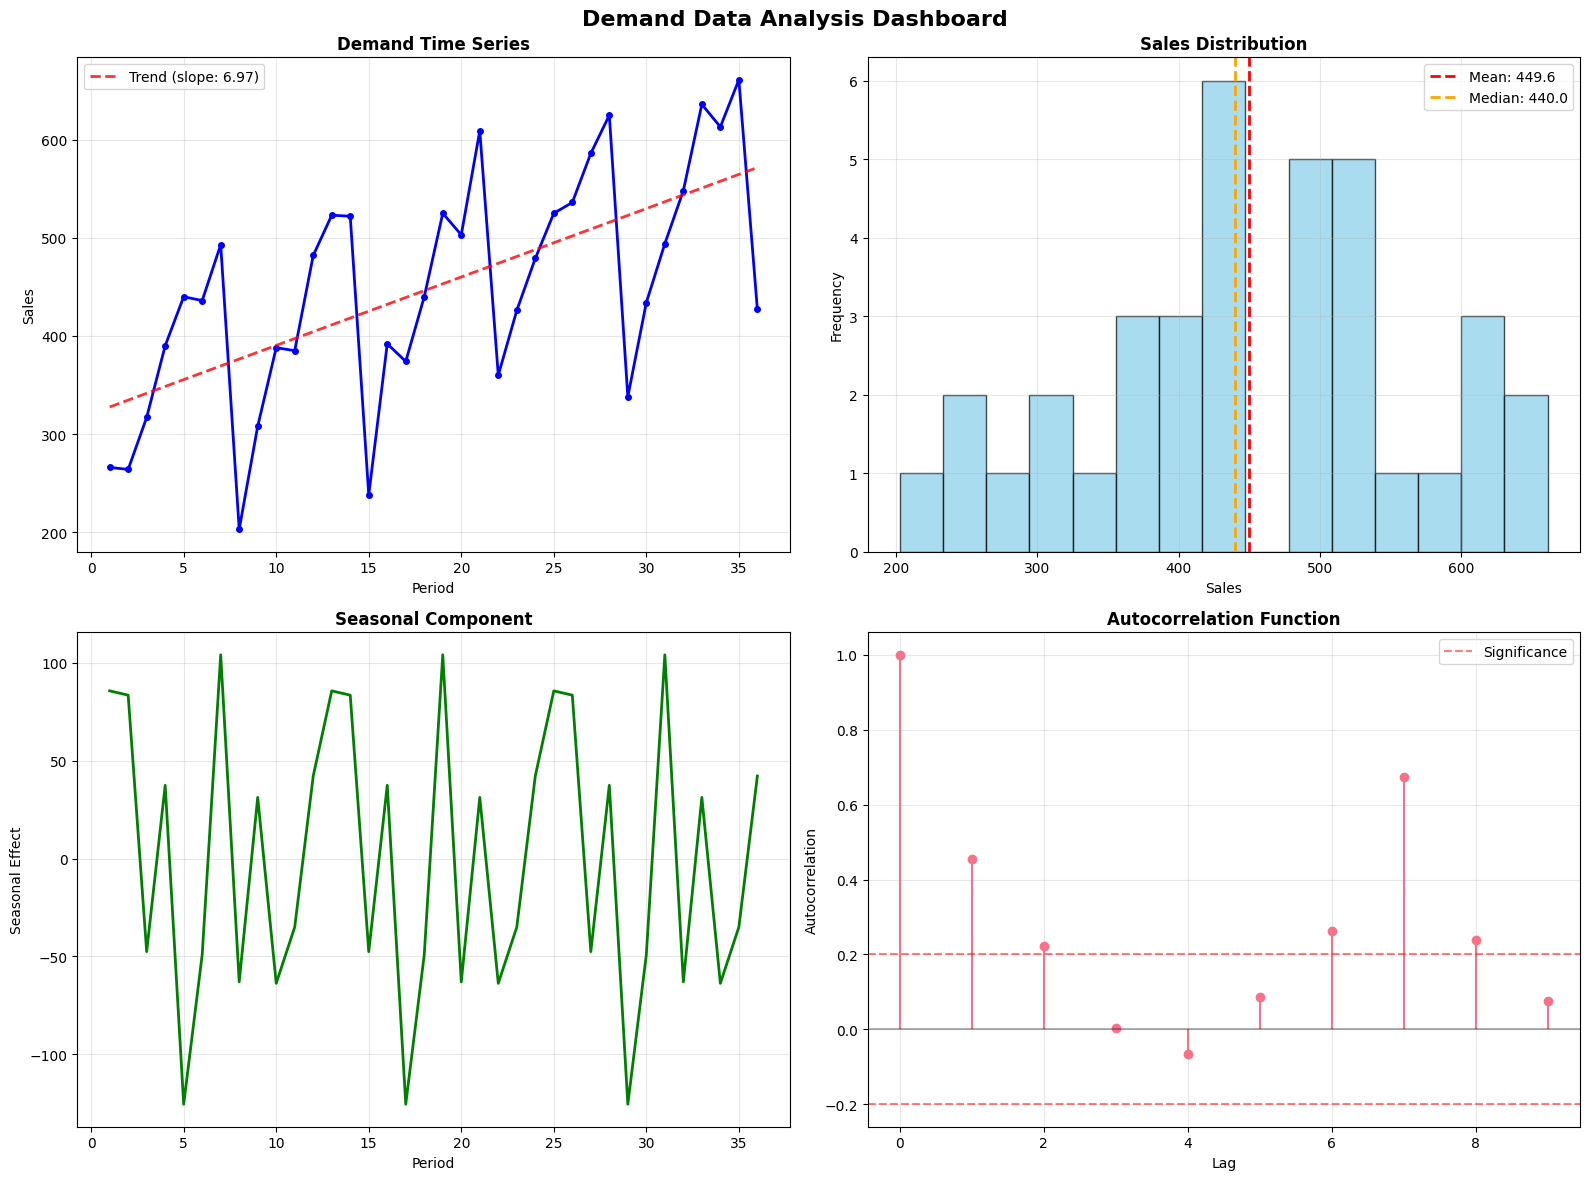


💾 ANALYSIS RESULTS DOWNLOAD
------------------------------


Button(button_style='info', description='📥 Download Analysis Report', layout=Layout(height='40px', width='250p…


🤖 INTELLIGENT MODEL SUGGESTIONS

🎯 TOP RECOMMENDED MODELS:
----------------------------------------
🥇 1. Triple Exponential Smoothing (Score: 98%)
   📋 Reason: Both trend and seasonality - Holt-Winters optimal

🥈 2. Prophet (Score: 95%)
   📋 Reason: Handles complex patterns with trend and seasonality

🥉 3. Seasonal ARIMA (Score: 90%)
   📋 Reason: Statistical approach for seasonal trending data

🏅 4. ARIMA (Score: 75%)
   📋 Reason: Flexible statistical model for various patterns

📊 DATA CHARACTERISTICS SUMMARY:
   • Trend: Yes (Strong)
   • Seasonality: Yes (Strong)
   • Stationarity: No
   • Variability: Low (CV: 0.261)
   • Data Points: 36


🔧 INTERACTIVE FORECASTING INTERFACE


✅ Complete forecast report generated successfully!


In [ ]:
# 📊 Advanced Demand Forecasting Tool - Complete Solution
# Interactive tool for comprehensive demand analysis and forecasting

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import io
import base64
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("📊 Installing required packages...")
# Install required packages
!pip install statsmodels prophet scikit-learn ipywidgets plotly openpyxl -q

import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from google.colab import files

# Import forecasting libraries
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("✅ All packages installed successfully!")
print("=" * 80)
print("🚀 ADVANCED DEMAND FORECASTING TOOL")
print("=" * 80)

class AdvancedDemandForecastingTool:
    def __init__(self):
        self.data = None
        self.analysis_results = {}
        self.forecast_results = {}
        self.model_suggestions = []
        self.sample_data = None

    def create_sample_data(self):
        """Create sample data based on uploaded file format"""
        sample_data = """period,sales
1,266
2,264
3,317
4,390
5,440
6,436
7,493
8,203
9,308
10,388
11,385
12,482
13,523
14,522
15,238
16,392
17,374
18,440
19,525
20,503
21,609
22,360
23,426
24,479
25,525
26,536
27,586
28,625
29,338
30,434
31,494
32,548
33,636
34,613
35,661
36,427"""
        return sample_data

    def start_application(self):
        """Main application interface"""
        print("📋 DEMAND FORECASTING DASHBOARD")
        print("=" * 50)
        print("Choose an option to get started:")
        print()

        # Create main menu buttons
        sample_button = widgets.Button(
            description='📥 Download Sample Data',
            button_style='info',
            layout=widgets.Layout(width='200px', height='45px')
        )

        upload_button = widgets.Button(
            description='📁 Upload Your Data',
            button_style='primary',
            layout=widgets.Layout(width='200px', height='45px')
        )

        demo_button = widgets.Button(
            description='🚀 Try Demo Analysis',
            button_style='success',
            layout=widgets.Layout(width='200px', height='45px')
        )

        def download_sample(b):
            clear_output(wait=True)
            self.provide_sample_download()

        def upload_data(b):
            clear_output(wait=True)
            self.upload_interface()

        def run_demo(b):
            clear_output(wait=True)
            self.load_demo_data()

        sample_button.on_click(download_sample)
        upload_button.on_click(upload_data)
        demo_button.on_click(run_demo)

        display(widgets.VBox([
            widgets.HTML("<h3>🎯 Select Your Approach:</h3>"),
            widgets.HBox([sample_button, upload_button, demo_button]),
            widgets.HTML("""
            <div style="margin-top: 20px; padding: 15px; background-color: #f8f9fa; border-radius: 5px;">
                <h4>📊 Expected Data Format:</h4>
                <p><strong>Columns:</strong> period, sales</p>
                <p><strong>Format:</strong> CSV or Excel file with header</p>
                <p><strong>Example:</strong></p>
                <pre>period,sales
1,266
2,264
3,317</pre>
                <p><strong>Minimum:</strong> 24+ periods recommended for accurate analysis</p>
            </div>
            """)
        ]))

    def provide_sample_download(self):
        """Provide sample data download"""
        print("📥 SAMPLE DATA DOWNLOAD")
        print("=" * 30)

        sample_data = self.create_sample_data()

        # Create download link
        b64 = base64.b64encode(sample_data.encode()).decode()
        filename = "sample_demand_data.csv"
        download_link = f'<a download="{filename}" href="data:text/csv;base64,{b64}" style="background-color: #007bff; color: white; padding: 10px 20px; text-decoration: none; border-radius: 5px;">📥 Download Sample Data File</a>'

        print("✅ Sample data ready for download!")
        print("📊 Contains 36 periods of demand data with seasonal patterns")
        print()
        display(HTML(download_link))

        # Back to main menu
        back_button = widgets.Button(
            description='🔙 Back to Main Menu',
            button_style='',  # Fixed: changed from 'secondary' to ''
            layout=widgets.Layout(width='200px', margin='20px 0px 0px 0px')
        )

        def go_back(b):
            clear_output(wait=True)
            self.start_application()

        back_button.on_click(go_back)
        display(back_button)

    def upload_interface(self):
        """File upload interface"""
        print("📁 DATA UPLOAD INTERFACE")
        print("=" * 30)

        upload_widget = widgets.FileUpload(
            accept='.csv,.xlsx',
            multiple=False,
            description='Choose File'
        )

        process_button = widgets.Button(
            description='📊 Analyze Data',
            button_style='success',
            layout=widgets.Layout(width='150px', height='40px')
        )

        back_button = widgets.Button(
            description='🔙 Back',
            button_style='',  # Fixed: changed from 'secondary' to ''
            layout=widgets.Layout(width='100px', height='40px')
        )

        def process_file(b):
            if upload_widget.value:
                try:
                    filename = list(upload_widget.value.keys())[0]
                    content = upload_widget.value[filename]['content']

                    # Save and read file
                    file_ext = filename.lower().split('.')[-1]

                    if file_ext == 'csv':
                        with open('uploaded_data.csv', 'wb') as f:
                            f.write(content)
                        self.data = pd.read_csv('uploaded_data.csv')
                    elif file_ext in ['xlsx', 'xls']:
                        with open('uploaded_data.xlsx', 'wb') as f:
                            f.write(content)
                        self.data = pd.read_excel('uploaded_data.xlsx')

                    # Validate data format
                    if not self.validate_data_format():
                        return

                    print("✅ File uploaded successfully!")
                    print(f"📊 Data shape: {self.data.shape}")
                    print(f"📅 Periods: {self.data['period'].min()} to {self.data['period'].max()}")

                    clear_output(wait=True)
                    self.start_analysis()

                except Exception as e:
                    print(f"❌ Error processing file: {str(e)}")
                    print("Please check your file format and try again.")
            else:
                print("❌ Please select a file first!")

        def go_back(b):
            clear_output(wait=True)
            self.start_application()

        process_button.on_click(process_file)
        back_button.on_click(go_back)

        display(widgets.VBox([
            widgets.HTML("<h4>📁 Upload Your Demand Data File</h4>"),
            upload_widget,
            widgets.HTML("<br>"),
            widgets.HBox([process_button, back_button])
        ]))

    def load_demo_data(self):
        """Load demo data for analysis"""
        print("🚀 LOADING DEMO DATA...")

        # Create DataFrame from sample data
        sample_lines = self.create_sample_data().strip().split('\n')
        data_rows = []

        for line in sample_lines[1:]:  # Skip header
            period, sales = line.split(',')
            data_rows.append({
                'period': int(period),
                'sales': float(sales)
            })

        self.data = pd.DataFrame(data_rows)

        print("✅ Demo data loaded successfully!")
        print(f"📊 Data contains {len(self.data)} periods")
        print(f"📈 Sales range: {self.data['sales'].min():.0f} to {self.data['sales'].max():.0f}")

        self.start_analysis()

    def validate_data_format(self):
        """Validate uploaded data format"""
        required_columns = ['period', 'sales']

        # Check if required columns exist (case insensitive)
        available_columns = [col.lower().strip() for col in self.data.columns]

        # Try to map columns
        column_mapping = {}
        for required in required_columns:
            found = False
            for i, col in enumerate(self.data.columns):
                if col.lower().strip() == required or col.lower().strip() == required.replace('sales', 'demand'):
                    column_mapping[required] = col
                    found = True
                    break
            if not found:
                print(f"❌ Missing required column: {required}")
                print(f"Available columns: {list(self.data.columns)}")
                return False

        # Rename columns to standard format
        if column_mapping:
            self.data = self.data.rename(columns=column_mapping)

        # If 'demand' column exists instead of 'sales', rename it
        if 'demand' in self.data.columns.str.lower():
            demand_col = [col for col in self.data.columns if col.lower() == 'demand'][0]
            self.data = self.data.rename(columns={demand_col: 'sales'})

        # Check data types
        try:
            self.data['period'] = pd.to_numeric(self.data['period'])
            self.data['sales'] = pd.to_numeric(self.data['sales'])
        except Exception as e:
            print(f"❌ Error converting data to numeric format: {str(e)}")
            return False

        # Remove any NaN values
        initial_len = len(self.data)
        self.data = self.data.dropna()
        if len(self.data) < initial_len:
            print(f"⚠️  Removed {initial_len - len(self.data)} rows with missing values")

        # Check for sufficient data
        if len(self.data) < 12:
            print("⚠️  Warning: Less than 12 periods of data. Results may be less accurate.")

        return True

    def start_analysis(self):
        """Start comprehensive data analysis"""
        print("📊 COMPREHENSIVE DATA ANALYSIS")
        print("=" * 50)

        # Perform all analysis steps
        self.analyze_data_characteristics()
        self.create_visualizations()
        self.suggest_models()
        self.create_forecasting_interface()

    def analyze_data_characteristics(self):
        """Analyze level, trend, and seasonality"""
        print("\n🔍 ANALYZING DATA CHARACTERISTICS...")

        # Basic statistics
        sales_data = self.data['sales']

        # Level analysis
        level = sales_data.mean()
        median = sales_data.median()
        std_dev = sales_data.std()
        cv = std_dev / level if level > 0 else 0

        # Trend analysis
        periods = self.data['period'].values
        trend_slope = np.polyfit(periods, sales_data.values, 1)[0]

        # Trend classification
        if abs(trend_slope) < 1:
            trend_type = "No Significant Trend"
            trend_strength = "Stable"
        elif trend_slope > 1:
            trend_type = f"Positive Trend (+{trend_slope:.2f} per period)"
            trend_strength = "Strong" if trend_slope > 5 else "Moderate"
        else:
            trend_type = f"Negative Trend ({trend_slope:.2f} per period)"
            trend_strength = "Strong" if trend_slope < -5 else "Moderate"

        # Seasonality analysis
        seasonality_info = self.analyze_seasonality()

        # Stationarity test
        try:
            adf_result = adfuller(sales_data.dropna())
            is_stationary = adf_result[1] < 0.05
            stationarity = "Stationary" if is_stationary else "Non-Stationary"
        except:
            is_stationary = False
            stationarity = "Unable to determine"
            adf_result = [None, 1.0]  # Default values

        # Store analysis results
        self.analysis_results = {
            'basic_stats': {
                'count': len(sales_data),
                'mean': round(level, 2),
                'median': round(median, 2),
                'std': round(std_dev, 2),
                'min': sales_data.min(),
                'max': sales_data.max(),
                'cv': round(cv, 3)
            },
            'trend': {
                'slope': round(trend_slope, 4),
                'type': trend_type,
                'strength': trend_strength,
                'has_trend': abs(trend_slope) > 1
            },
            'seasonality': seasonality_info,
            'stationarity': {
                'is_stationary': is_stationary,
                'status': stationarity,
                'adf_pvalue': adf_result[1] if adf_result[1] is not None else 'N/A'
            }
        }

        # Display results
        self.display_analysis_results()

    def analyze_seasonality(self):
        """Detailed seasonality analysis"""
        sales_data = self.data['sales']

        if len(sales_data) < 24:  # Not enough data for proper seasonal analysis
            return {
                'has_seasonality': False,
                'strength': 'Insufficient data',
                'period': 'N/A',
                'type': 'Cannot determine'
            }

        try:
            # Try different seasonal periods
            seasonal_periods = [12, 6, 4]  # Monthly, bi-monthly, quarterly
            best_seasonal = None
            best_strength = 0

            for period in seasonal_periods:
                if len(sales_data) >= 2 * period:
                    try:
                        decomposition = seasonal_decompose(sales_data, model='additive', period=period)
                        seasonal_strength = decomposition.seasonal.std() / sales_data.std()

                        if seasonal_strength > best_strength:
                            best_strength = seasonal_strength
                            best_seasonal = {
                                'period': period,
                                'strength': seasonal_strength,
                                'decomposition': decomposition
                            }
                    except:
                        continue

            if best_seasonal:
                strength_level = (
                    "Strong" if best_strength > 0.3 else
                    "Moderate" if best_strength > 0.1 else
                    "Weak"
                )

                return {
                    'has_seasonality': best_strength > 0.1,
                    'strength': strength_level,
                    'period': best_seasonal['period'],
                    'strength_value': round(best_strength, 3),
                    'decomposition': best_seasonal['decomposition']
                }
            else:
                return {
                    'has_seasonality': False,
                    'strength': 'None detected',
                    'period': 'N/A',
                    'type': 'No clear pattern'
                }

        except Exception as e:
            return {
                'has_seasonality': False,
                'strength': 'Analysis failed',
                'period': 'N/A',
                'error': str(e)
            }

    def display_analysis_results(self):
        """Display comprehensive analysis results"""
        print("\n📋 ANALYSIS RESULTS")
        print("=" * 40)

        # Basic Statistics
        basic = self.analysis_results['basic_stats']
        print(f"\n📊 Basic Statistics:")
        print(f"   Data Points: {basic['count']}")
        print(f"   Mean: {basic['mean']}")
        print(f"   Median: {basic['median']}")
        print(f"   Std Deviation: {basic['std']}")
        print(f"   Range: {basic['min']} - {basic['max']}")
        print(f"   Coefficient of Variation: {basic['cv']}")

        # Trend Analysis
        trend = self.analysis_results['trend']
        print(f"\n📈 Trend Analysis:")
        print(f"   Type: {trend['type']}")
        print(f"   Strength: {trend['strength']}")
        print(f"   Slope: {trend['slope']} units per period")

        # Seasonality Analysis
        seasonal = self.analysis_results['seasonality']
        print(f"\n🔄 Seasonality Analysis:")
        print(f"   Seasonality Detected: {'Yes' if seasonal['has_seasonality'] else 'No'}")
        print(f"   Strength: {seasonal['strength']}")
        if seasonal['has_seasonality']:
            print(f"   Seasonal Period: {seasonal['period']} periods")
            print(f"   Strength Value: {seasonal.get('strength_value', 'N/A')}")

        # Stationarity
        stationarity = self.analysis_results['stationarity']
        print(f"\n🎯 Stationarity:")
        print(f"   Status: {stationarity['status']}")
        if stationarity['adf_pvalue'] != 'N/A':
            print(f"   ADF p-value: {stationarity['adf_pvalue']:.6f}")

        # Data Quality Assessment
        print(f"\n✅ Data Quality Assessment:")
        if basic['count'] >= 36:
            print("   📈 Excellent: Sufficient data for robust analysis")
        elif basic['count'] >= 24:
            print("   👍 Good: Adequate data for most models")
        else:
            print("   ⚠️  Fair: Limited data, results may be less reliable")

        if basic['cv'] < 0.5:
            print("   📊 Low variability - suitable for most models")
        elif basic['cv'] < 1.0:
            print("   📊 Moderate variability - consider robust models")
        else:
            print("   📊 High variability - use caution with forecasts")

    def create_visualizations(self):
        """Create comprehensive visualizations"""
        print("\n📊 CREATING VISUALIZATIONS...")

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('Demand Data Analysis Dashboard', fontsize=16, fontweight='bold')

        sales_data = self.data['sales']
        periods = self.data['period']

        # 1. Time Series Plot
        ax1 = axes[0, 0]
        ax1.plot(periods, sales_data, linewidth=2, marker='o', markersize=4, color='blue')
        ax1.set_title('Demand Time Series', fontweight='bold')
        ax1.set_xlabel('Period')
        ax1.set_ylabel('Sales')
        ax1.grid(True, alpha=0.3)

        # Add trend line
        z = np.polyfit(periods, sales_data, 1)
        p = np.poly1d(z)
        ax1.plot(periods, p(periods), "r--", alpha=0.8, linewidth=2, label=f'Trend (slope: {z[0]:.2f})')
        ax1.legend()

        # 2. Distribution
        ax2 = axes[0, 1]
        ax2.hist(sales_data, bins=15, alpha=0.7, color='skyblue', edgecolor='black')
        ax2.axvline(sales_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {sales_data.mean():.1f}')
        ax2.axvline(sales_data.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {sales_data.median():.1f}')
        ax2.set_title('Sales Distribution', fontweight='bold')
        ax2.set_xlabel('Sales')
        ax2.set_ylabel('Frequency')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # 3. Seasonal Decomposition (if available)
        if self.analysis_results['seasonality']['has_seasonality'] and 'decomposition' in self.analysis_results['seasonality']:
            ax3 = axes[1, 0]
            decomp = self.analysis_results['seasonality']['decomposition']
            seasonal_data = decomp.seasonal.iloc[:len(periods)]
            ax3.plot(periods, seasonal_data, color='green', linewidth=2)
            ax3.set_title('Seasonal Component', fontweight='bold')
            ax3.set_xlabel('Period')
            ax3.set_ylabel('Seasonal Effect')
            ax3.grid(True, alpha=0.3)
        else:
            ax3 = axes[1, 0]
            ax3.text(0.5, 0.5, 'Seasonality not detected\nor insufficient data',
                    ha='center', va='center', transform=ax3.transAxes, fontsize=12)
            ax3.set_title('Seasonal Component', fontweight='bold')

        # 4. Autocorrelation
        ax4 = axes[1, 1]
        try:
            autocorr = acf(sales_data.dropna(), nlags=min(20, len(sales_data)//4))
            lags = range(len(autocorr))
            ax4.stem(lags, autocorr, basefmt=" ")
            ax4.axhline(y=0, color='black', linestyle='-', alpha=0.3)
            ax4.axhline(y=0.2, color='red', linestyle='--', alpha=0.5, label='Significance')
            ax4.axhline(y=-0.2, color='red', linestyle='--', alpha=0.5)
            ax4.set_title('Autocorrelation Function', fontweight='bold')
            ax4.set_xlabel('Lag')
            ax4.set_ylabel('Autocorrelation')
            ax4.legend()
            ax4.grid(True, alpha=0.3)
        except:
            ax4.text(0.5, 0.5, 'Autocorrelation\nanalysis failed',
                    ha='center', va='center', transform=ax4.transAxes, fontsize=12)
            ax4.set_title('Autocorrelation Function', fontweight='bold')

        plt.tight_layout()
        plt.show()

        # Create analysis download button
        self.create_analysis_download_button()

    def create_analysis_download_button(self):
        """Create button to download analysis results"""
        print("\n💾 ANALYSIS RESULTS DOWNLOAD")
        print("-" * 30)

        download_button = widgets.Button(
            description='📥 Download Analysis Report',
            button_style='info',
            layout=widgets.Layout(width='250px', height='40px')
        )

        def download_analysis(b):
            try:
                output = io.BytesIO()

                with pd.ExcelWriter(output, engine='openpyxl') as writer:
                    # Original data
                    self.data.to_excel(writer, sheet_name='Original_Data', index=False)

                    # Analysis summary
                    analysis_summary = []

                    # Basic stats
                    for key, value in self.analysis_results['basic_stats'].items():
                        analysis_summary.append({'Category': 'Basic Statistics', 'Metric': key, 'Value': value})

                    # Trend info
                    for key, value in self.analysis_results['trend'].items():
                        analysis_summary.append({'Category': 'Trend Analysis', 'Metric': key, 'Value': value})

                    # Seasonality info
                    for key, value in self.analysis_results['seasonality'].items():
                        if key != 'decomposition':  # Skip the decomposition object
                            analysis_summary.append({'Category': 'Seasonality', 'Metric': key, 'Value': value})

                    # Stationarity info
                    for key, value in self.analysis_results['stationarity'].items():
                        analysis_summary.append({'Category': 'Stationarity', 'Metric': key, 'Value': value})

                    summary_df = pd.DataFrame(analysis_summary)
                    summary_df.to_excel(writer, sheet_name='Analysis_Summary', index=False)

                output.seek(0)

                # Create download link
                b64 = base64.b64encode(output.getvalue()).decode()
                timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
                filename = f"demand_analysis_report_{timestamp}.xlsx"

                download_link = f'<a download="{filename}" href="data:application/vnd.openxmlformats-officedocument.spreadsheetml.sheet;base64,{b64}" style="background-color: #17a2b8; color: white; padding: 10px 20px; text-decoration: none; border-radius: 5px;">📥 Download Analysis Report</a>'
                display(HTML(download_link))

                print("✅ Analysis report ready for download!")

            except Exception as e:
                print(f"❌ Error creating analysis report: {str(e)}")

        download_button.on_click(download_analysis)
        display(download_button)

    def suggest_models(self):
        """Suggest best forecasting models based on data characteristics"""
        print("\n🤖 INTELLIGENT MODEL SUGGESTIONS")
        print("=" * 50)

        # Get analysis results
        has_trend = self.analysis_results['trend']['has_trend']
        has_seasonality = self.analysis_results['seasonality']['has_seasonality']
        is_stationary = self.analysis_results['stationarity']['is_stationary']
        cv = self.analysis_results['basic_stats']['cv']
        data_points = self.analysis_results['basic_stats']['count']

        suggestions = []

        # Model selection logic
        if not has_trend and not has_seasonality and cv < 0.3:
            suggestions.extend([
                {'model': 'Simple Exponential Smoothing', 'score': 95, 'reason': 'Stable data with low variability - perfect for simple smoothing'},
                {'model': 'Moving Average', 'score': 85, 'reason': 'Stable pattern suitable for averaging methods'},
                {'model': 'Naive', 'score': 70, 'reason': 'Good baseline for stable data'}
            ])

        elif has_trend and not has_seasonality:
            suggestions.extend([
                {'model': 'Double Exponential Smoothing', 'score': 95, 'reason': 'Clear trend detected - Holt\'s method ideal'},
                {'model': 'Linear Trend', 'score': 85, 'reason': 'Simple trend can be captured with linear model'},
                {'model': 'ARIMA', 'score': 80, 'reason': 'Flexible for trending data'}
            ])

        elif has_seasonality and not has_trend:
            suggestions.extend([
                {'model': 'Triple Exponential Smoothing', 'score': 95, 'reason': 'Seasonality detected - Holt-Winters perfect choice'},
                {'model': 'Seasonal Naive', 'score': 80, 'reason': 'Simple seasonal approach'},
                {'model': 'Prophet', 'score': 85, 'reason': 'Excellent for seasonal patterns'}
            ])

        elif has_trend and has_seasonality:
            suggestions.extend([
                {'model': 'Triple Exponential Smoothing', 'score': 98, 'reason': 'Both trend and seasonality - Holt-Winters optimal'},
                {'model': 'Prophet', 'score': 95, 'reason': 'Handles complex patterns with trend and seasonality'},
                {'model': 'Seasonal ARIMA', 'score': 90, 'reason': 'Statistical approach for seasonal trending data'}
            ])

        # Add versatile models
        if data_points >= 24:
            if 'ARIMA' not in [s['model'] for s in suggestions]:
                suggestions.append({'model': 'ARIMA', 'score': 75, 'reason': 'Flexible statistical model for various patterns'})

            if 'Prophet' not in [s['model'] for s in suggestions]:
                suggestions.append({'model': 'Prophet', 'score': 80, 'reason': 'Modern robust forecasting method'})

        # High variability adjustments
        if cv > 1.0:
            for suggestion in suggestions:
                if suggestion['model'] in ['Prophet', 'ARIMA', 'Seasonal ARIMA']:
                    suggestion['score'] += 10  # Boost robust methods
                    suggestion['reason'] += ' (robust to high variability)'

        # Sort by score
        suggestions.sort(key=lambda x: x['score'], reverse=True)

        # Keep top 5 suggestions
        self.model_suggestions = suggestions[:5]

        # Display suggestions
        print("\n🎯 TOP RECOMMENDED MODELS:")
        print("-" * 40)

        for i, suggestion in enumerate(self.model_suggestions, 1):
            score = suggestion['score']
            emoji = "🥇" if i == 1 else "🥈" if i == 2 else "🥉" if i == 3 else "🏅"

            print(f"{emoji} {i}. {suggestion['model']} (Score: {score}%)")
            print(f"   📋 Reason: {suggestion['reason']}")
            print()

        # Display data characteristics summary
        print("📊 DATA CHARACTERISTICS SUMMARY:")
        print(f"   • Trend: {'Yes' if has_trend else 'No'} ({self.analysis_results['trend']['strength']})")
        print(f"   • Seasonality: {'Yes' if has_seasonality else 'No'} ({self.analysis_results['seasonality']['strength']})")
        print(f"   • Stationarity: {'Yes' if is_stationary else 'No'}")
        print(f"   • Variability: {'High' if cv > 1 else 'Moderate' if cv > 0.5 else 'Low'} (CV: {cv:.3f})")
        print(f"   • Data Points: {data_points}")

    def create_forecasting_interface(self):
        """Create interactive forecasting interface"""
        print("\n\n🔧 INTERACTIVE FORECASTING INTERFACE")
        print("=" * 60)

        # Model selection dropdown
        model_options = [s['model'] for s in self.model_suggestions]
        if not model_options:
            model_options = ['Simple Exponential Smoothing', 'ARIMA', 'Prophet']

        model_dropdown = widgets.Dropdown(
            options=model_options,
            value=model_options[0],
            description='Select Model:',
            style={'description_width': 'initial'},
            layout=widgets.Layout(width='350px')
        )

        # Forecast horizon
        horizon_slider = widgets.IntSlider(
            value=6,
            min=1,
            max=24,
            step=1,
            description='Forecast Periods:',
            style={'description_width': 'initial'}
        )

        # Parameter container (will be populated based on model)
        param_container = widgets.VBox([])

        # Model parameters based on selection
        def update_parameters(change):
            model = change['new']
            param_widgets = []

            if model == 'Simple Exponential Smoothing':
                param_widgets.extend([
                    widgets.HTML("<p><strong>Alpha (α)</strong>: Level smoothing parameter</p>"),
                    widgets.FloatSlider(value=0.3, min=0.1, max=0.9, step=0.1,
                                      description='Alpha (α):', style={'description_width': '100px'},
                                      continuous_update=False),
                ])

            elif model == 'Double Exponential Smoothing':
                param_widgets.extend([
                    widgets.HTML("<p><strong>Alpha (α)</strong>: Level smoothing | <strong>Beta (β)</strong>: Trend smoothing</p>"),
                    widgets.FloatSlider(value=0.3, min=0.1, max=0.9, step=0.1,
                                      description='Alpha (α):', style={'description_width': '100px'},
                                      continuous_update=False),
                    widgets.FloatSlider(value=0.3, min=0.1, max=0.9, step=0.1,
                                      description='Beta (β):', style={'description_width': '100px'},
                                      continuous_update=False)
                ])

            elif model == 'Triple Exponential Smoothing':
                param_widgets.extend([
                    widgets.HTML("<p><strong>Alpha (α)</strong>: Level | <strong>Beta (β)</strong>: Trend | <strong>Gamma (γ)</strong>: Seasonal</p>"),
                    widgets.FloatSlider(value=0.3, min=0.1, max=0.9, step=0.1,
                                      description='Alpha (α):', style={'description_width': '100px'},
                                      continuous_update=False),
                    widgets.FloatSlider(value=0.3, min=0.1, max=0.9, step=0.1,
                                      description='Beta (β):', style={'description_width': '100px'},
                                      continuous_update=False),
                    widgets.FloatSlider(value=0.3, min=0.1, max=0.9, step=0.1,
                                      description='Gamma (γ):', style={'description_width': '100px'},
                                      continuous_update=False),
                    widgets.Dropdown(options=['additive', 'multiplicative'], value='additive',
                                   description='Seasonal Type:', style={'description_width': '100px'})
                ])

            elif model == 'ARIMA':
                param_widgets.extend([
                    widgets.HTML("<p><strong>p</strong>: Autoregressive order | <strong>d</strong>: Differencing | <strong>q</strong>: Moving average</p>"),
                    widgets.IntSlider(value=1, min=0, max=5, description='p (AR):',
                                    style={'description_width': '100px'}),
                    widgets.IntSlider(value=1, min=0, max=2, description='d (I):',
                                    style={'description_width': '100px'}),
                    widgets.IntSlider(value=1, min=0, max=5, description='q (MA):',
                                    style={'description_width': '100px'})
                ])

            elif model == 'Seasonal ARIMA':
                param_widgets.extend([
                    widgets.HTML("<p><strong>SARIMA Parameters</strong>: (p,d,q) × (P,D,Q,s)</p>"),
                    widgets.IntSlider(value=1, min=0, max=3, description='p:', style={'description_width': '100px'}),
                    widgets.IntSlider(value=1, min=0, max=2, description='d:', style={'description_width': '100px'}),
                    widgets.IntSlider(value=1, min=0, max=3, description='q:', style={'description_width': '100px'}),
                    widgets.IntSlider(value=1, min=0, max=2, description='P (seasonal):', style={'description_width': '100px'}),
                    widgets.IntSlider(value=1, min=0, max=1, description='D (seasonal):', style={'description_width': '100px'}),
                    widgets.IntSlider(value=1, min=0, max=2, description='Q (seasonal):', style={'description_width': '100px'}),
                    widgets.IntSlider(value=12, min=4, max=12, description='Season Length:', style={'description_width': '100px'})
                ])

            elif model == 'Moving Average':
                param_widgets.extend([
                    widgets.HTML("<p><strong>Window Size</strong>: Number of periods to average</p>"),
                    widgets.IntSlider(value=3, min=2, max=12, description='Window Size:',
                                    style={'description_width': '100px'})
                ])

            param_container.children = param_widgets

        # Set up observers
        model_dropdown.observe(update_parameters, names='value')
        update_parameters({'new': model_dropdown.value})  # Initialize

        # Forecast button
        forecast_button = widgets.Button(
            description='🚀 Generate Forecast',
            button_style='success',
            layout=widgets.Layout(width='200px', height='45px')
        )

        # Results container
        results_output = widgets.Output()

        def run_forecast(b):
            with results_output:
                clear_output(wait=True)
                try:
                    selected_model = model_dropdown.value
                    forecast_horizon = horizon_slider.value

                    # Extract parameters
                    params = {}
                    for widget in param_container.children:
                        if hasattr(widget, 'description') and hasattr(widget, 'value') and widget.description:
                            param_name = widget.description.replace(':', '').strip()
                            params[param_name] = widget.value

                    print(f"🚀 Running {selected_model} forecast...")
                    print(f"📊 Parameters: {params}")
                    print("=" * 50)

                    # Run forecast
                    forecast_result = self.run_forecasting_model(selected_model, params, forecast_horizon)

                    if forecast_result:
                        self.display_forecast_results(forecast_result)
                        self.create_forecast_download_button(forecast_result)
                    else:
                        print("❌ Forecasting failed. Please try different parameters.")

                except Exception as e:
                    print(f"❌ Error in forecasting: {str(e)}")

        forecast_button.on_click(run_forecast)

        # Display interface
        interface = widgets.VBox([
            widgets.HTML("<h3>🎯 Configure Forecasting Parameters</h3>"),
            model_dropdown,
            horizon_slider,
            widgets.HTML("<h4>📊 Model Parameters:</h4>"),
            param_container,
            widgets.HTML("<br>"),
            forecast_button,
            widgets.HTML("<br>"),
            results_output
        ])

        display(interface)

    def run_forecasting_model(self, model_name, params, forecast_horizon):
        """Run the selected forecasting model"""
        try:
            sales_data = self.data['sales']

            # Split data for validation
            split_point = max(6, len(sales_data) - 6)
            train_data = sales_data[:split_point]
            test_data = sales_data[split_point:] if split_point < len(sales_data) else pd.Series(dtype=float)

            # Initialize variables
            train_forecast = None
            test_forecast = []
            future_forecast = []
            model_formula = ""
            fitted_params = {}

            if model_name == 'Simple Exponential Smoothing':
                alpha = params.get('Alpha (α)', 0.3)
                model = ExponentialSmoothing(train_data, trend=None, seasonal=None)
                fitted_model = model.fit(smoothing_level=alpha, optimized=False)

                train_forecast = fitted_model.fittedvalues
                future_forecast = fitted_model.forecast(steps=forecast_horizon).tolist()
                test_forecast = fitted_model.forecast(steps=len(test_data)).tolist() if len(test_data) > 0 else []

                model_formula = f"F(t+1) = {alpha:.3f} × X(t) + {1-alpha:.3f} × F(t)"
                fitted_params = {'alpha': alpha}

            elif model_name == 'Double Exponential Smoothing':
                alpha = params.get('Alpha (α)', 0.3)
                beta = params.get('Beta (β)', 0.3)

                model = ExponentialSmoothing(train_data, trend='add', seasonal=None)
                fitted_model = model.fit(smoothing_level=alpha, smoothing_trend=beta, optimized=False)

                train_forecast = fitted_model.fittedvalues
                future_forecast = fitted_model.forecast(steps=forecast_horizon).tolist()
                test_forecast = fitted_model.forecast(steps=len(test_data)).tolist() if len(test_data) > 0 else []

                model_formula = f"Level: L(t) = {alpha:.3f}×X(t) + {1-alpha:.3f}×(L(t-1)+T(t-1)); Trend: T(t) = {beta:.3f}×(L(t)-L(t-1)) + {1-beta:.3f}×T(t-1)"
                fitted_params = {'alpha': alpha, 'beta': beta}

            elif model_name == 'Triple Exponential Smoothing':
                alpha = params.get('Alpha (α)', 0.3)
                beta = params.get('Beta (β)', 0.3)
                gamma = params.get('Gamma (γ)', 0.3)
                seasonal_type = params.get('Seasonal Type', 'additive')

                seasonal_periods = self.analysis_results['seasonality'].get('period', 12)

                try:
                    model = ExponentialSmoothing(train_data, trend='add', seasonal=seasonal_type, seasonal_periods=seasonal_periods)
                    fitted_model = model.fit(smoothing_level=alpha, smoothing_trend=beta, smoothing_seasonal=gamma, optimized=False)
                except:
                    # Fallback to double smoothing if seasonal fails
                    model = ExponentialSmoothing(train_data, trend='add', seasonal=None)
                    fitted_model = model.fit(smoothing_level=alpha, smoothing_trend=beta, optimized=False)
                    seasonal_type = 'none (fallback)'

                train_forecast = fitted_model.fittedvalues
                future_forecast = fitted_model.forecast(steps=forecast_horizon).tolist()
                test_forecast = fitted_model.forecast(steps=len(test_data)).tolist() if len(test_data) > 0 else []

                model_formula = f"Holt-Winters {seasonal_type} model with α={alpha:.3f}, β={beta:.3f}, γ={gamma:.3f}, period={seasonal_periods}"
                fitted_params = {'alpha': alpha, 'beta': beta, 'gamma': gamma, 'seasonal_type': seasonal_type}

            elif model_name == 'ARIMA':
                p = params.get('p (AR)', 1)
                d = params.get('d (I)', 1)
                q = params.get('q (MA)', 1)

                model = ARIMA(train_data, order=(p, d, q))
                fitted_model = model.fit()

                train_forecast = fitted_model.fittedvalues
                future_forecast = fitted_model.forecast(steps=forecast_horizon).tolist()
                test_forecast = fitted_model.forecast(steps=len(test_data)).tolist() if len(test_data) > 0 else []

                model_formula = f"ARIMA({p},{d},{q}): Autoregressive order {p}, Differencing {d}, Moving Average {q}"
                fitted_params = {'p': p, 'd': d, 'q': q}

            elif model_name == 'Seasonal ARIMA':
                p, d, q = params.get('p', 1), params.get('d', 1), params.get('q', 1)
                P, D, Q = params.get('P (seasonal)', 1), params.get('D (seasonal)', 1), params.get('Q (seasonal)', 1)
                s = params.get('Season Length', 12)

                try:
                    model = ARIMA(train_data, order=(p, d, q), seasonal_order=(P, D, Q, s))
                    fitted_model = model.fit()
                except:
                    # Fallback to regular ARIMA
                    model = ARIMA(train_data, order=(p, d, q))
                    fitted_model = model.fit()
                    s = 'none (fallback)'

                train_forecast = fitted_model.fittedvalues
                future_forecast = fitted_model.forecast(steps=forecast_horizon).tolist()
                test_forecast = fitted_model.forecast(steps=len(test_data)).tolist() if len(test_data) > 0 else []

                model_formula = f"SARIMA({p},{d},{q})×({P},{D},{Q},{s}): Seasonal ARIMA with period {s}"
                fitted_params = {'p': p, 'd': d, 'q': q, 'P': P, 'D': D, 'Q': Q, 's': s}

            elif model_name == 'Prophet':
                # Prepare data for Prophet
                train_periods = range(1, len(train_data) + 1)
                prophet_train = pd.DataFrame({
                    'ds': pd.date_range(start='2020-01-01', periods=len(train_data), freq='M'),
                    'y': train_data.values
                })

                model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
                fitted_model = model.fit(prophet_train)

                # Future dates
                future_dates = fitted_model.make_future_dataframe(periods=forecast_horizon, freq='M')
                forecast_data = fitted_model.predict(future_dates)

                train_forecast = forecast_data['yhat'][:len(train_data)]
                future_forecast = forecast_data['yhat'][-forecast_horizon:].tolist()

                if len(test_data) > 0:
                    test_dates = pd.DataFrame({
                        'ds': pd.date_range(start=prophet_train['ds'].iloc[-1] + pd.DateOffset(months=1),
                                          periods=len(test_data), freq='M')
                    })
                    test_pred = fitted_model.predict(test_dates)
                    test_forecast = test_pred['yhat'].tolist()

                model_formula = "Prophet: y(t) = g(t) + s(t) + h(t) + ε(t) where g=trend, s=seasonality, h=holidays"
                fitted_params = {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 10.0}

            elif model_name == 'Moving Average':
                window = params.get('Window Size', 3)

                train_forecast = train_data.rolling(window=window).mean()

                # Future forecast - use last 'window' values
                last_values = sales_data.tail(window)
                future_forecast = [last_values.mean()] * forecast_horizon

                # Test forecast
                test_forecast = []
                for i in range(len(test_data)):
                    if i == 0:
                        test_forecast.append(train_data.tail(window).mean())
                    else:
                        recent_values = sales_data.iloc[split_point+i-window:split_point+i]
                        test_forecast.append(recent_values.mean() if len(recent_values) > 0 else test_forecast[-1])

                model_formula = f"Moving Average with window size {window}: F(t) = (X(t-1) + ... + X(t-{window}))/{window}"
                fitted_params = {'window_size': window}

            elif model_name == 'Naive':
                train_forecast = train_data.shift(1)
                future_forecast = [train_data.iloc[-1]] * forecast_horizon
                test_forecast = [train_data.iloc[-1]] * len(test_data) if len(test_data) > 0 else []

                model_formula = "Naive: F(t+1) = X(t)"
                fitted_params = {}

            elif model_name == 'Seasonal Naive':
                seasonal_period = self.analysis_results['seasonality'].get('period', 12)

                train_forecast = train_data.shift(seasonal_period)

                # Future forecast using seasonal pattern
                future_forecast = []
                for i in range(forecast_horizon):
                    seasonal_idx = len(sales_data) - seasonal_period + (i % seasonal_period)
                    if seasonal_idx >= 0 and seasonal_idx < len(sales_data):
                        future_forecast.append(sales_data.iloc[seasonal_idx])
                    else:
                        future_forecast.append(sales_data.iloc[-1])

                # Test forecast
                test_forecast = []
                for i in range(len(test_data)):
                    seasonal_idx = split_point + i - seasonal_period
                    if seasonal_idx >= 0:
                        test_forecast.append(sales_data.iloc[seasonal_idx])
                    else:
                        test_forecast.append(train_data.iloc[-1])

                model_formula = f"Seasonal Naive with period {seasonal_period}: F(t+s) = X(t)"
                fitted_params = {'seasonal_period': seasonal_period}

            elif model_name == 'Linear Trend':
                x = np.arange(len(train_data))
                coeffs = np.polyfit(x, train_data.values, 1)

                train_forecast = pd.Series(np.polyval(coeffs, x), index=train_data.index)

                # Future forecast
                x_future = np.arange(len(train_data), len(train_data) + forecast_horizon)
                future_forecast = np.polyval(coeffs, x_future).tolist()

                # Test forecast
                if len(test_data) > 0:
                    x_test = np.arange(len(train_data), len(sales_data))
                    test_forecast = np.polyval(coeffs, x_test).tolist()

                model_formula = f"Linear Trend: F(t) = {coeffs[1]:.3f} + {coeffs[0]:.3f} × t"
                fitted_params = {'intercept': coeffs[1], 'slope': coeffs[0]}

            # Calculate error metrics
            error_metrics = self.calculate_error_metrics(test_data, test_forecast, train_data, train_forecast)

            # Prepare result
            return {
                'model_name': model_name,
                'model_formula': model_formula,
                'fitted_params': fitted_params,
                'forecast_horizon': forecast_horizon,
                'train_data': train_data,
                'test_data': test_data,
                'train_forecast': train_forecast,
                'test_forecast': test_forecast,
                'future_forecast': future_forecast,
                'error_metrics': error_metrics,
                'forecast_periods': list(range(len(sales_data) + 1, len(sales_data) + 1 + forecast_horizon))
            }

        except Exception as e:
            print(f"❌ Error in {model_name}: {str(e)}")
            return None

    def calculate_error_metrics(self, test_data, test_forecast, train_data, train_forecast):
        """Calculate comprehensive error metrics"""
        metrics = {}

        # Test data metrics (if available)
        if len(test_forecast) > 0 and len(test_data) > 0:
            min_len = min(len(test_forecast), len(test_data))
            test_actual = test_data.values[:min_len]
            test_pred = np.array(test_forecast[:min_len])

            # Remove any NaN values
            valid_mask = ~(np.isnan(test_actual) | np.isnan(test_pred))
            if np.any(valid_mask):
                test_actual = test_actual[valid_mask]
                test_pred = test_pred[valid_mask]

                if len(test_actual) > 0:
                    # MAPE
                    mape = np.mean(np.abs((test_actual - test_pred) / np.where(test_actual != 0, test_actual, 1))) * 100

                    # RMSE
                    rmse = np.sqrt(mean_squared_error(test_actual, test_pred))

                    # MSE
                    mse = mean_squared_error(test_actual, test_pred)

                    # MAE
                    mae = mean_absolute_error(test_actual, test_pred)

                    # Additional metrics
                    # Mean Bias Error
                    mbe = np.mean(test_pred - test_actual)

                    # Symmetric MAPE
                    smape = np.mean(2 * np.abs(test_actual - test_pred) / (np.abs(test_actual) + np.abs(test_pred) + 1e-8)) * 100

                    # Theil's U statistic
                    try:
                        u_stat = np.sqrt(np.mean((test_pred - test_actual)**2)) / (np.sqrt(np.mean(test_actual**2)) + np.sqrt(np.mean(test_pred**2)) + 1e-8)
                    except:
                        u_stat = np.nan

                    metrics['test'] = {
                        'MAPE': round(mape, 2),
                        'RMSE': round(rmse, 2),
                        'MSE': round(mse, 2),
                        'MAE': round(mae, 2),
                        'MBE': round(mbe, 2),
                        'SMAPE': round(smape, 2),
                        'Theil_U': round(u_stat, 4) if not np.isnan(u_stat) else 'N/A'
                    }

                    # Accuracy assessment
                    if mape < 10:
                        accuracy = "Excellent"
                    elif mape < 20:
                        accuracy = "Good"
                    elif mape < 30:
                        accuracy = "Fair"
                    else:
                        accuracy = "Poor"

                    metrics['test']['Accuracy_Rating'] = accuracy

        # Training data metrics (in-sample fit)
        if train_forecast is not None and len(train_data) > 0:
            try:
                if hasattr(train_forecast, 'dropna'):
                    train_forecast_clean = train_forecast.dropna()
                    train_data_clean = train_data.loc[train_forecast_clean.index]
                else:
                    train_forecast_clean = np.array(train_forecast)
                    train_data_clean = train_data.values[:len(train_forecast_clean)]

                    # Remove NaN values
                    valid_mask = ~np.isnan(train_forecast_clean)
                    train_forecast_clean = train_forecast_clean[valid_mask]
                    train_data_clean = train_data_clean[valid_mask]

                if len(train_data_clean) > 0 and len(train_forecast_clean) > 0:
                    train_mape = np.mean(np.abs((train_data_clean - train_forecast_clean) / np.where(train_data_clean != 0, train_data_clean, 1))) * 100
                    train_rmse = np.sqrt(mean_squared_error(train_data_clean, train_forecast_clean))

                    metrics['train'] = {
                        'MAPE': round(train_mape, 2),
                        'RMSE': round(train_rmse, 2)
                    }
            except:
                pass

        return metrics

    def display_forecast_results(self, results):
        """Display comprehensive forecast results"""
        print(f"✅ {results['model_name']} - FORECAST RESULTS")
        print("=" * 60)

        # Display model information
        print(f"📐 Model Formula: {results['model_formula']}")
        print(f"🎯 Parameters: {results['fitted_params']}")
        print(f"📅 Forecast Horizon: {results['forecast_horizon']} periods")

        # Display error metrics
        if 'test' in results['error_metrics']:
            test_metrics = results['error_metrics']['test']
            print(f"\n📊 MODEL PERFORMANCE METRICS:")
            print(f"   MAPE: {test_metrics['MAPE']}%")
            print(f"   RMSE: {test_metrics['RMSE']}")
            print(f"   MSE:  {test_metrics['MSE']}")
            print(f"   MAE:  {test_metrics['MAE']}")
            print(f"   MBE (Bias): {test_metrics['MBE']}")
            print(f"   SMAPE: {test_metrics['SMAPE']}%")
            print(f"   Theil's U: {test_metrics['Theil_U']}")
            print(f"   📈 Accuracy Rating: {test_metrics['Accuracy_Rating']}")

        if 'train' in results['error_metrics']:
            train_metrics = results['error_metrics']['train']
            print(f"\n📋 IN-SAMPLE FIT:")
            print(f"   Training MAPE: {train_metrics['MAPE']}%")
            print(f"   Training RMSE: {train_metrics['RMSE']}")

        # Create visualizations
        self.create_forecast_visualizations(results)

        # Display forecast table
        print(f"\n🔮 FUTURE FORECAST VALUES:")
        print("-" * 30)

        forecast_df = pd.DataFrame({
            'Period': results['forecast_periods'],
            'Forecasted_Sales': [round(val, 2) for val in results['future_forecast']]
        })
        print(forecast_df.to_string(index=False))

        # Store results
        self.forecast_results[results['model_name']] = results

    def create_forecast_visualizations(self, results):
        """Create comprehensive forecast visualizations"""
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle(f'{results["model_name"]} - Forecast Analysis', fontsize=16, fontweight='bold')

        # 1. Main forecast plot
        ax1 = axes[0, 0]

        # Historical data
        train_periods = list(range(1, len(results['train_data']) + 1))
        ax1.plot(train_periods, results['train_data'].values,
                label='Historical Data', color='blue', linewidth=2, marker='o', markersize=4)

        # Test data if available
        if len(results['test_data']) > 0:
            test_periods = list(range(len(results['train_data']) + 1, len(results['train_data']) + len(results['test_data']) + 1))
            ax1.plot(test_periods, results['test_data'].values,
                    label='Actual Test Data', color='green', linewidth=2, marker='s', markersize=4)

        # Model fit
        if results['train_forecast'] is not None:
            try:
                if hasattr(results['train_forecast'], 'values'):
                    fit_data = results['train_forecast'].values
                else:
                    fit_data = results['train_forecast']

                ax1.plot(train_periods[:len(fit_data)], fit_data,
                        label='Model Fit', color='orange', linewidth=2, alpha=0.8)
            except:
                pass

        # Test forecast
        if len(results['test_forecast']) > 0 and len(results['test_data']) > 0:
            test_periods = list(range(len(results['train_data']) + 1, len(results['train_data']) + len(results['test_forecast']) + 1))
            ax1.plot(test_periods, results['test_forecast'],
                    label='Test Forecast', color='red', linewidth=2, marker='^', markersize=4)

        # Future forecast
        ax1.plot(results['forecast_periods'], results['future_forecast'],
                label='Future Forecast', color='purple', linewidth=3, marker='*', markersize=8)

        ax1.set_title('Forecast Results', fontweight='bold')
        ax1.set_xlabel('Period')
        ax1.set_ylabel('Sales')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # 2. Residuals plot
        ax2 = axes[0, 1]
        if len(results['test_data']) > 0 and len(results['test_forecast']) > 0:
            min_len = min(len(results['test_data']), len(results['test_forecast']))
            residuals = results['test_data'].values[:min_len] - np.array(results['test_forecast'][:min_len])
            test_periods = list(range(len(results['train_data']) + 1, len(results['train_data']) + min_len + 1))

            ax2.plot(test_periods, residuals, color='red', marker='o', linewidth=2)
            ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
            ax2.set_title('Forecast Residuals', fontweight='bold')
            ax2.set_xlabel('Period')
            ax2.set_ylabel('Residual (Actual - Forecast)')
            ax2.grid(True, alpha=0.3)
        else:
            ax2.text(0.5, 0.5, 'No test data available\nfor residual analysis',
                    ha='center', va='center', transform=ax2.transAxes, fontsize=12)
            ax2.set_title('Forecast Residuals', fontweight='bold')

        # 3. Error metrics visualization
        ax3 = axes[1, 0]
        if 'test' in results['error_metrics']:
            metrics = results['error_metrics']['test']
            metric_names = ['MAPE', 'RMSE', 'MAE', 'SMAPE']
            metric_values = [metrics.get(name, 0) for name in metric_names]

            bars = ax3.bar(metric_names, metric_values, alpha=0.7, color=['red', 'orange', 'blue', 'green'])
            ax3.set_title('Error Metrics', fontweight='bold')
            ax3.set_ylabel('Error Value')

            # Add value labels on bars
            for bar, value in zip(bars, metric_values):
                height = bar.get_height()
                ax3.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                        f'{value:.2f}', ha='center', va='bottom')

            ax3.grid(True, alpha=0.3)
        else:
            ax3.text(0.5, 0.5, 'No error metrics\navailable',
                    ha='center', va='center', transform=ax3.transAxes, fontsize=12)
            ax3.set_title('Error Metrics', fontweight='bold')

        # 4. Forecast vs Actual (if test data available)
        ax4 = axes[1, 1]
        if len(results['test_data']) > 0 and len(results['test_forecast']) > 0:
            min_len = min(len(results['test_data']), len(results['test_forecast']))
            actual_vals = results['test_data'].values[:min_len]
            forecast_vals = np.array(results['test_forecast'][:min_len])

            ax4.scatter(actual_vals, forecast_vals, alpha=0.7, color='blue')

            # Perfect prediction line
            min_val = min(actual_vals.min(), forecast_vals.min())
            max_val = max(actual_vals.max(), forecast_vals.max())
            ax4.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=2, label='Perfect Forecast')

            ax4.set_title('Actual vs Forecast', fontweight='bold')
            ax4.set_xlabel('Actual Sales')
            ax4.set_ylabel('Forecasted Sales')
            ax4.legend()
            ax4.grid(True, alpha=0.3)
        else:
            ax4.text(0.5, 0.5, 'No test data available\nfor comparison',
                    ha='center', va='center', transform=ax4.transAxes, fontsize=12)
            ax4.set_title('Actual vs Forecast', fontweight='bold')

        plt.tight_layout()
        plt.show()

    def create_forecast_download_button(self, results):
        """Create comprehensive download for forecast results"""
        print("\n💾 COMPREHENSIVE FORECAST REPORT DOWNLOAD")
        print("=" * 50)

        download_button = widgets.Button(
            description='📥 Download Complete Report',
            button_style='warning',
            layout=widgets.Layout(width='300px', height='45px')
        )

        def download_complete_report(b):
            try:
                output = io.BytesIO()

                with pd.ExcelWriter(output, engine='openpyxl') as writer:
                    # 1. Original input data
                    self.data.to_excel(writer, sheet_name='01_Input_Data', index=False)

                    # 2. Data analysis summary
                    analysis_summary = []

                    # Basic statistics
                    for key, value in self.analysis_results['basic_stats'].items():
                        analysis_summary.append({'Category': 'Basic Statistics', 'Metric': key, 'Value': value})

                    # Trend analysis
                    for key, value in self.analysis_results['trend'].items():
                        analysis_summary.append({'Category': 'Trend Analysis', 'Metric': key, 'Value': value})

                    # Seasonality analysis
                    for key, value in self.analysis_results['seasonality'].items():
                        if key != 'decomposition':
                            analysis_summary.append({'Category': 'Seasonality', 'Metric': key, 'Value': value})

                    # Stationarity
                    for key, value in self.analysis_results['stationarity'].items():
                        analysis_summary.append({'Category': 'Stationarity', 'Metric': key, 'Value': value})

                    analysis_df = pd.DataFrame(analysis_summary)
                    analysis_df.to_excel(writer, sheet_name='02_Data_Analysis', index=False)

                    # 3. Model information and parameters
                    model_info = []
                    model_info.append({'Attribute': 'Model Name', 'Value': results['model_name']})
                    model_info.append({'Attribute': 'Formula', 'Value': results['model_formula']})
                    model_info.append({'Attribute': 'Forecast Horizon', 'Value': results['forecast_horizon']})

                    for param, value in results['fitted_params'].items():
                        model_info.append({'Attribute': f'Parameter_{param}', 'Value': value})

                    model_info_df = pd.DataFrame(model_info)
                    model_info_df.to_excel(writer, sheet_name='03_Model_Details', index=False)

                    # 4. Error metrics
                    error_data = []
                    if 'test' in results['error_metrics']:
                        for metric, value in results['error_metrics']['test'].items():
                            error_data.append({'Metric_Type': 'Out-of-Sample', 'Metric': metric, 'Value': value})

                    if 'train' in results['error_metrics']:
                        for metric, value in results['error_metrics']['train'].items():
                            error_data.append({'Metric_Type': 'In-Sample', 'Metric': metric, 'Value': value})

                    if error_data:
                        error_df = pd.DataFrame(error_data)
                        error_df.to_excel(writer, sheet_name='04_Error_Metrics', index=False)

                    # 5. Historical data with fitted values
                    historical_data = []
                    train_periods = list(range(1, len(results['train_data']) + 1))

                    for i, period in enumerate(train_periods):
                        row = {
                            'Period': period,
                            'Actual_Sales': results['train_data'].iloc[i] if i < len(results['train_data']) else None,
                            'Fitted_Values': None
                        }

                        if results['train_forecast'] is not None:
                            try:
                                if hasattr(results['train_forecast'], 'iloc'):
                                    if i < len(results['train_forecast']):
                                        row['Fitted_Values'] = results['train_forecast'].iloc[i]
                                else:
                                    if i < len(results['train_forecast']):
                                        row['Fitted_Values'] = results['train_forecast'][i]
                            except:
                                pass

                        historical_data.append(row)

                    # Add test data if available
                    if len(results['test_data']) > 0:
                        test_periods = list(range(len(results['train_data']) + 1,
                                                len(results['train_data']) + len(results['test_data']) + 1))

                        for i, period in enumerate(test_periods):
                            row = {
                                'Period': period,
                                'Actual_Sales': results['test_data'].iloc[i] if i < len(results['test_data']) else None,
                                'Fitted_Values': results['test_forecast'][i] if i < len(results['test_forecast']) else None
                            }
                            historical_data.append(row)

                    historical_df = pd.DataFrame(historical_data)
                    historical_df.to_excel(writer, sheet_name='05_Historical_Fit', index=False)

                    # 6. Future forecast
                    forecast_df = pd.DataFrame({
                        'Future_Period': results['forecast_periods'],
                        'Forecasted_Sales': results['future_forecast'],
                        'Model_Used': results['model_name'],
                        'Formula': results['model_formula']
                    })

                    # Add confidence intervals if available (simplified)
                    forecast_std = np.std(results['future_forecast']) if len(results['future_forecast']) > 1 else 0
                    forecast_df['Lower_95%_CI'] = [max(0, val - 1.96 * forecast_std) for val in results['future_forecast']]
                    forecast_df['Upper_95%_CI'] = [val + 1.96 * forecast_std for val in results['future_forecast']]

                    forecast_df.to_excel(writer, sheet_name='06_Future_Forecast', index=False)

                    # 7. Model recommendations and important parameters
                    recommendations = []
                    recommendations.append({
                        'Parameter': 'Model Suitability',
                        'Value': f"Chosen based on data characteristics - {results['model_name']}",
                        'Importance': 'Critical for forecast accuracy'
                    })

                    if 'test' in results['error_metrics']:
                        mape = results['error_metrics']['test']['MAPE']
                        recommendations.append({
                            'Parameter': 'Forecast Accuracy',
                            'Value': f"{mape}% MAPE - {results['error_metrics']['test']['Accuracy_Rating']}",
                            'Importance': 'Key performance indicator'
                        })

                    # Data characteristics
                    recommendations.extend([
                        {
                            'Parameter': 'Trend Presence',
                            'Value': 'Yes' if self.analysis_results['trend']['has_trend'] else 'No',
                            'Importance': 'Affects model selection'
                        },
                        {
                            'Parameter': 'Seasonality',
                            'Value': 'Yes' if self.analysis_results['seasonality']['has_seasonality'] else 'No',
                            'Importance': 'Critical for pattern recognition'
                        },
                        {
                            'Parameter': 'Data Variability',
                            'Value': f"CV = {self.analysis_results['basic_stats']['cv']:.3f}",
                            'Importance': 'Impacts forecast reliability'
                        }
                    ])

                    recommendations_df = pd.DataFrame(recommendations)
                    recommendations_df.to_excel(writer, sheet_name='07_Key_Parameters', index=False)

                output.seek(0)

                # Create download link
                b64 = base64.b64encode(output.getvalue()).decode()
                timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
                filename = f"complete_demand_forecast_report_{results['model_name']}_{timestamp}.xlsx"

                download_link = f'''
                <div style="background-color: #f8f9fa; padding: 20px; border-radius: 10px; margin: 10px 0;">
                    <h4 style="color: #28a745;">📊 Complete Forecast Report Ready!</h4>
                    <p><strong>File includes:</strong></p>
                    <ul>
                        <li>✅ Original input data</li>
                        <li>✅ Comprehensive data analysis (Level, Trend, Seasonality)</li>
                        <li>✅ Model details and formulas</li>
                        <li>✅ Error metrics (MAPE, RMSE, MSE, MAE, etc.)</li>
                        <li>✅ Historical fit and future forecasts</li>
                        <li>✅ Key parameters and recommendations</li>
                    </ul>
                    <a download="{filename}" href="data:application/vnd.openxmlformats-officedocument.spreadsheetml.sheet;base64,{b64}"
                       style="background-color: #28a745; color: white; padding: 15px 30px; text-decoration: none; border-radius: 5px; font-weight: bold;">
                       📥 Download Complete Report
                    </a>
                </div>
                '''

                display(HTML(download_link))
                print("✅ Complete forecast report generated successfully!")

            except Exception as e:
                print(f"❌ Error creating complete report: {str(e)}")

        download_button.on_click(download_complete_report)
        display(download_button)

# Initialize and start the application
print("🚀 ADVANCED DEMAND FORECASTING TOOL")
print("=" * 80)
print("This comprehensive tool provides:")
print("✅ Intelligent data analysis (Level, Trend, Seasonality)")
print("✅ Smart model suggestions with explanations")
print("✅ Interactive parameter tuning (α, β, γ values)")
print("✅ Comprehensive error metrics (MAPE, RMSE, MSE, MAE)")
print("✅ Professional reporting and downloads")
print("✅ Business-aligned forecasting solutions")
print()

# Create and start the tool
tool = AdvancedDemandForecastingTool()
tool.start_application()
